# NAMA  : FIRAZ AFIFUDIN
# NIM   : 221351051

In [36]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv ('Diabetes1.csv')

In [38]:
df.head()

,Age,BMI,Blood_Sugar_Level,Family_History,Diet,Diabetes
0,45,28.7,135,Yes,Poor,Yes
1,50,31.2,145,No,Moderate,Yes
2,30,22.0,95,No,Good,No
3,35,25.4,105,Yes,Poor,Yes
4,60,33.5,155,Yes,Poor,Yes


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                20 non-null     int64  
 1   BMI                20 non-null     float64
 2   Blood_Sugar_Level  20 non-null     int64  
 3   Family_History     20 non-null     object 
 4   Diet               20 non-null     object 
 5   Diabetes           20 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 1.1+ KB


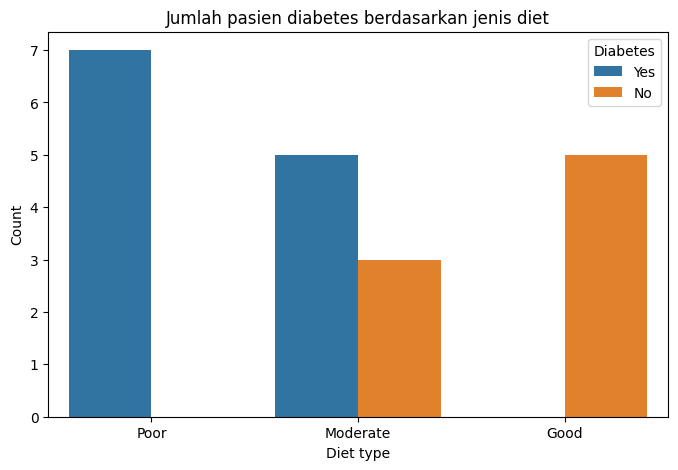

In [40]:
plt.figure (figsize=(8, 5))
sns.countplot(x='Diet', hue='Diabetes', data=df)
plt.title("Jumlah pasien diabetes berdasarkan jenis diet")
plt.xlabel("Diet type")
plt.ylabel("Count")
plt.legend(title="Diabetes")
plt.show()

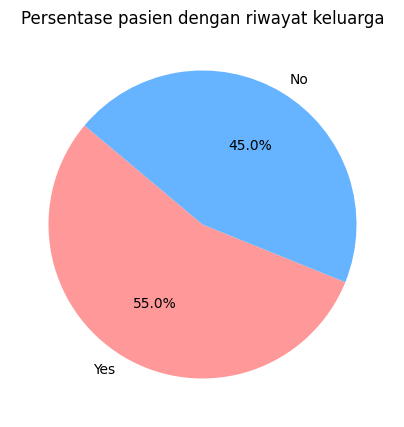

In [41]:
family_history_counts = df['Family_History'].value_counts()
plt.figure(figsize=(5,5))
family_history_counts.plot.pie(autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title("Persentase pasien dengan riwayat keluarga")
plt.ylabel("")
plt.show()

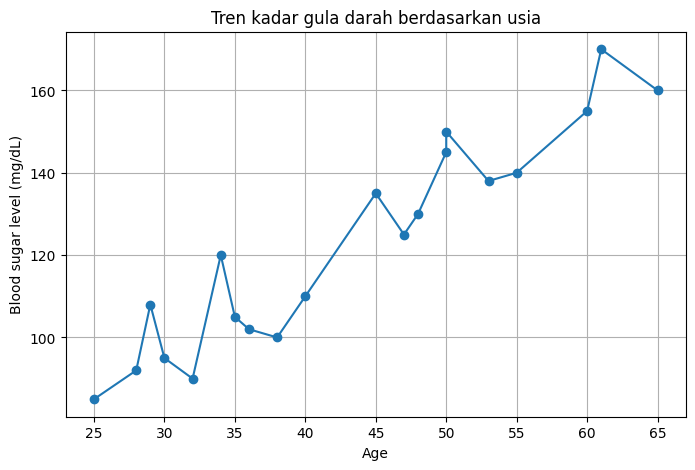

In [42]:
df_sorted = df.sort_values(by='Age')
plt.figure(figsize=(8,5))
plt.plot(df_sorted['Age'], df_sorted['Blood_Sugar_Level'], marker='o')
plt.title("Tren kadar gula darah berdasarkan usia")
plt.xlabel("Age")
plt.ylabel("Blood sugar level (mg/dL)")
plt.grid(True)
plt.show()

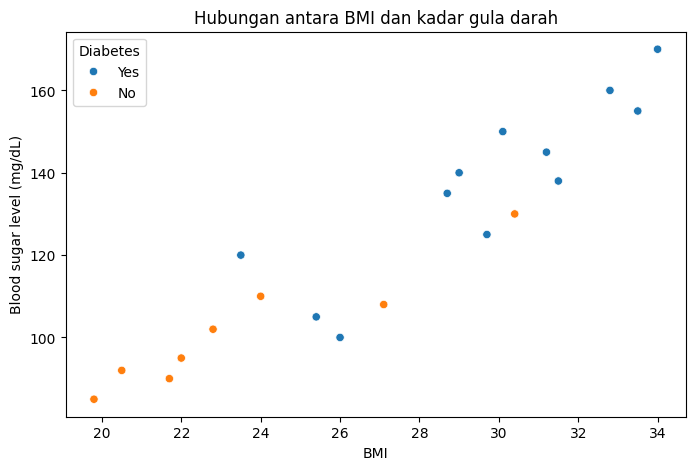

In [43]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='BMI', y='Blood_Sugar_Level', hue='Diabetes', data=df)
plt.title("Hubungan antara BMI dan kadar gula darah")
plt.xlabel("BMI")
plt.ylabel("Blood sugar level (mg/dL)")
plt.legend(title="Diabetes")
plt.show()

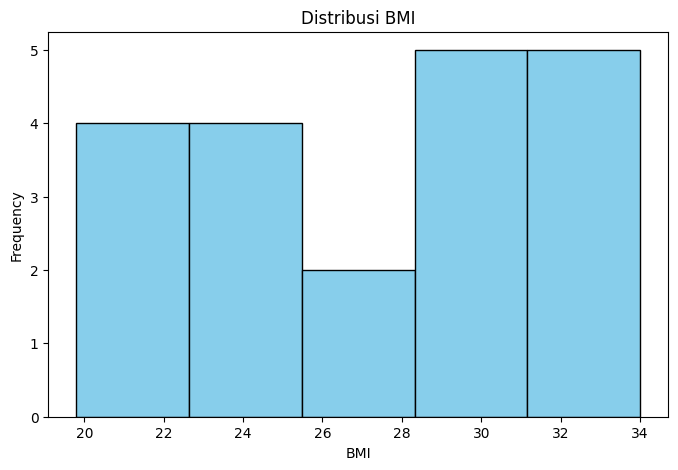

In [44]:
plt.figure(figsize=(8, 5))
plt.hist(df['BMI'], bins=5, color='skyblue', edgecolor='black')
plt.title("Distribusi BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

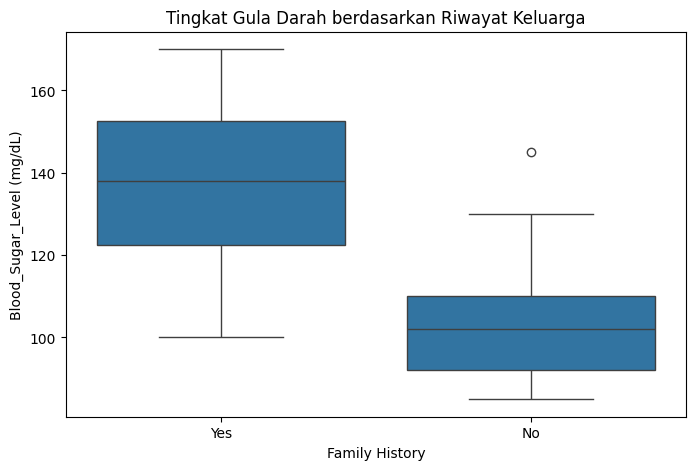

In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Family_History', y='Blood_Sugar_Level', data=df)
plt.title("Tingkat Gula Darah berdasarkan Riwayat Keluarga")
plt.xlabel("Family History")
plt.ylabel("Blood_Sugar_Level (mg/dL)")
plt.show()

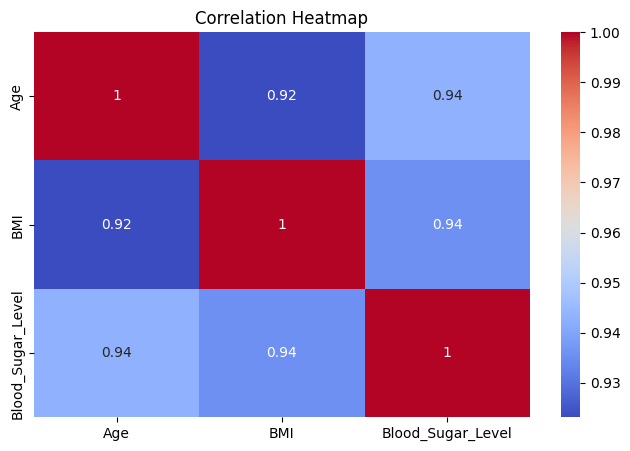

In [46]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Age', 'BMI', 'Blood_Sugar_Level']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

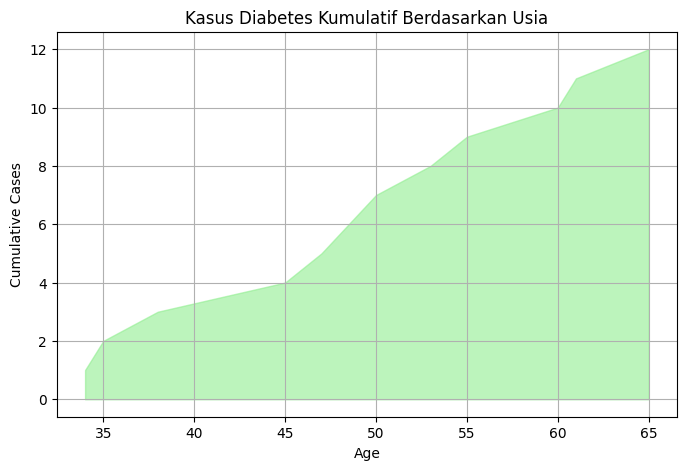

In [47]:
age_cum_cases = df[df['Diabetes'] == 'Yes'].groupby('Age').size().cumsum()
plt.figure(figsize=(8, 5))
plt.fill_between(age_cum_cases.index, age_cum_cases.values, color='lightgreen', alpha=0.6)
plt.title("Kasus Diabetes Kumulatif Berdasarkan Usia")
plt.xlabel("Age")
plt.ylabel("Cumulative Cases")
plt.grid(True)
plt.show()

In [48]:
df_encoded = pd.DataFrame(df)

In [49]:
df_encoded['Family_History'] = df_encoded['Family_History'].map({'Yes': 1, 'No': 0})
df_encoded['Diet'] = df_encoded['Diet'].map({'Poor': 0, 'Moderate': 1, 'Good': 2})
df_encoded['Diabetes'] = df_encoded['Diabetes'].map({'Yes': 1, 'No': 0})

In [50]:
df_encoded.head()

,Age,BMI,Blood_Sugar_Level,Family_History,Diet,Diabetes
0,45,28.7,135,1,0,1
1,50,31.2,145,0,1,1
2,30,22.0,95,0,2,0
3,35,25.4,105,1,0,1
4,60,33.5,155,1,0,1


In [51]:
categorical_df = df_encoded.copy()
categorical_df['Age'] = pd.cut (categorical_df['Age'], bins = [0, 30, 40, 50, 60, 80], labels = [0, 1, 2, 3, 4])
categorical_df['BMI'] = pd.cut (categorical_df['BMI'], bins = [0, 18.5, 24.9, 29.9, 50], labels = [0, 1, 2, 3])
categorical_df['Blood_Sugar_Level'] = pd.cut (categorical_df['Blood_Sugar_Level'], bins = [0, 100, 125, 150, 200], labels = [0, 1, 2, 3])

In [52]:
categorical_df.head()

,Age,BMI,Blood_Sugar_Level,Family_History,Diet,Diabetes
0,2,2,2,1,0,1
1,2,3,2,0,1,1
2,0,1,0,0,2,0
3,1,2,1,1,0,1
4,3,3,3,1,0,1


In [53]:
X_categorical = categorical_df[['Age', 'BMI', 'Blood_Sugar_Level', 'Family_History', 'Diet']]
y_categorical = categorical_df['Diabetes']

In [54]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_categorical, y_categorical, test_size=0.3, random_state=42)

In [55]:
cat_nb_model = CategoricalNB()
cat_nb_model.fit(X_train_cat, y_train_cat)

CategoricalNB()

In [56]:
y_pered_cat = cat_nb_model.predict(X_test_cat)

In [57]:
new_data_categorical = np.array([[3, 2, 1, 1, 0]])
new_prediction_cat = cat_nb_model.predict(new_data_categorical)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but CategoricalNB was fitted with feature names
  warnings.warn(


In [58]:
(new_prediction_cat)

array([1])

In [59]:
if (new_prediction_cat == 1):
  print("Pasien tidak terkena diabetes")
else:
  print("Pasien terkena diabetes")

Pasien tidak terkena diabetes


In [60]:
cat_accuracy = accuracy_score(y_test_cat, y_pered_cat)

In [61]:
cat_conf_matrix = confusion_matrix(y_test_cat, y_pered_cat)

In [62]:
(cat_accuracy, cat_conf_matrix)

(0.8333333333333334,
 array([[2, 0],
        [1, 3]]))

In [63]:
import pickle

filename = 'cat_diabetes_mod.pkl'
pickle.dump(cat_nb_model, open(filename, 'wb'))

In [64]:
pip install streamlit

In [65]:
import streamlit as st
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open('cat_diabetes_mod.pkl', 'rb') as model_file:
    model = pickle.load(model_file)

st.title('Categorical Naive Bayes - Diabetes Prediction')

st.sidebar.header ("Input Data Baru ")
age = st.sidebar.selectbox("Age", ["<30", "30-40", "50-60", "60+"])
bmi = st.sidebar.selectbox("BMI", ["<18.5", "18.5-24.9", "25-29.9", "30+"])
blood_sugar = st.sidebar.selectbox("Blood Sugar Level", ["<100", "100-125", "126-150", ">150+"])
family_history = st.sidebar.selectbox("Family History of Diabetes", ["No", "Yes"])
diet = st.sidebar.selectbox("Diet", ["Good", "Moderate", "Poor"])

age_map = {"<30": 0,"30-40": 1, "50-60": 2, "60+": 3}
bmi_map = {"<18.5": 0, "18.5-24.9": 1, "25-29.9": 2, "30+": 3}
blood_sugar_map = {"<100": 0, "100-125": 1, "125-150": 2, "150+": 3}
family_history_map = {"No": 0, "Yes": 1}
diet_map = {"Good": 2, "Moderate": 1, "Poor": 0}


input_data = np.array([[age_map[age], bmi_map[bmi], blood_sugar_map[blood_sugar],
                        family_history_map[family_history], diet_map[diet]]])


prediction = model.predict(input_data)
prediction_prob = model.predict_proba (input_data)



st.subheader("Prediction Result")
result = "Diabetes (Yes)" if prediction [0] == 1 else "No Diabetes"
st.write(f"The model predicts: **{result}**")


fig, ax = plt.subplots()
labels = ['No Diabetes', 'Diabetes']
ax.bar(labels, prediction_prob[0], color=['green', 'red'])
ax.set_ylabel('Probability')
ax.set_title('Prediction Probability')
st.pyplot(fig)


st.subheader("Input Summary")
st.write(f"**Age**: {age}")
st.write(f"**BMI**: {bmi}")
st.write(f"**Blood Sugar Level**: {blood_sugar}")
st.write(f"**Family History**: {family_history}")
st.write(f"**Diet**: {diet}")

2025-10-27 04:17:16.151 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-27 04:17:16.152 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-27 04:17:16.153 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-27 04:17:16.154 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-27 04:17:16.155 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-27 04:17:16.156 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-27 04:17:16.156 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-27 04:17:16.157 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar